In [1]:
import numpy as np

import grid2op
from grid2op.Action import PlayableAction
from grid2op.Parameters import Parameters
import matplotlib.pyplot as plt

In [6]:
# try:
#     from lightsim2grid import LightSimBackend
#     bk_cls = LightSimBackend
# except ImportError as exc:
#     print(f"Error: {exc} when importing faster LightSimBackend")
from grid2op.Backend import PandaPowerBackend
bk_cls = PandaPowerBackend

In [7]:
param = Parameters()
param.NO_OVERFLOW_DISCONNECTION = True

In [8]:
env1 = grid2op.make("educ_case14_storage",
                    test=True,
                    action_class=PlayableAction,
                    param=param,
                    backend=bk_cls(with_numba=False))

/qfs/projects/gridpack_wind/grid2op_interface/grid2op/grid2op/MakeEnv/Make.py:482: UserWarning: You are using a development environment. This environment is not intended for training agents. It might not be up to date and its primary use if for tests (hence the "test=True" you passed as argument). Use at your own risk.
  warnings.warn(_MAKE_DEV_ENV_WARN)


In [9]:
# Curtailment action
gen_id = 2  # because we want to act on generator 2
amount_ratio = 0.1  # that is the 7% of the limit

In [10]:
# method 1
curtail_act_1 = env1.action_space({"curtail": [(gen_id, amount_ratio)]})

In [11]:
# method 2
curtail_vect = np.zeros(env1.n_gen) - 1.
curtail_vect[gen_id] = amount_ratio
curtail_act_2 = env1.action_space({"curtail": curtail_vect})

In [12]:
# method 3
curtail_act_3 = env1.action_space()
curtail_act_3.curtail = [(gen_id, amount_ratio)]

In [13]:
# method 4
curtail_act_4 = env1.action_space()
curtail_act_4.curtail = curtail_vect

In [14]:
# all these actions are equal
print(curtail_act_4)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT modify any storage capacity
	 - Perform the following curtailment:
	 	 - Limit unit "gen_5_2" to 10.0% of its Pmax (setpoint: 0.100)
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


## Note
One "side effect" of applying a curtailment action can be redispatching. Indeed, the balance between production and load should maintain. The data (before curtailment) meets this criteria. This means that whatever curtailment is performed should be absorbed somehow.

We decided to have the dispatchable generators produce more to compensate the curtailment. This behaviour is showed in the cell below.

In [15]:
env1.set_id(0)
obs_init = env1.reset()
obs, *_ = env1.step(curtail_act_1)
print(f"Amount of MW curtailed for generator {gen_id}: {obs.curtailment_mw[gen_id]:.2f} MW")
print(f"Sum of redispatched generator: {obs.actual_dispatch.sum():.2f} MW")

Amount of MW curtailed for generator 2: 9.90 MW
Sum of redispatched generator: 9.90 MW


## Note
Finally, curtailment action will perdure on time. This means that if you perform a curtailment action on a step, unless you modify it later on.

In this example above, the generator with id 2 will be constrained to produce less than 15% of its maximum production until you change that.



In [16]:
print(f"Curtailment setpoint for generator {gen_id}: {obs.curtailment_limit[gen_id]:.2f} "
      f"({obs.curtailment_limit_mw[gen_id]:.2f} MW)")

# we perform a do nothing action
obs0, *_ = env1.step(env1.action_space())
print(f"Curtailment setpoint for generator {gen_id} (after do nothing action): "
      f"{obs0.curtailment_limit[gen_id]:.2f} "
      f"({obs0.curtailment_limit_mw[gen_id]:.2f} MW)")
# we perform a do nothing action
obs1, *_ = env1.step(env1.action_space())
print(f"Curtailment setpoint for generator {gen_id} (after a second do nothing action): "
      f"{obs1.curtailment_limit[gen_id]:.2f} "
      f"({obs1.curtailment_limit_mw[gen_id]:.2f} MW)")
# we perform a do nothing action
obs2, *_ = env1.step(env1.action_space())
print(f"Curtailment setpoint for generator {gen_id} (after a third do nothing action): "
      f"{obs2.curtailment_limit[gen_id]:.2f} "
      f"({obs2.curtailment_limit_mw[gen_id]:.2f} MW)")

Curtailment setpoint for generator 2: 0.10 (7.00 MW)
Curtailment setpoint for generator 2 (after do nothing action): 0.10 (7.00 MW)
Curtailment setpoint for generator 2 (after a second do nothing action): 0.10 (7.00 MW)
Curtailment setpoint for generator 2 (after a third do nothing action): 0.10 (7.00 MW)


In [17]:
# we perform an action to remove the curtailment
curtail_act_reset = env1.action_space({"curtail": [(gen_id, 1.0)]})
obs3, *_ = env1.step(curtail_act_reset)
print(f"Curtailment setpoint for generator {gen_id} (after setting the curtailment to 100% again): "
      f"{obs3.curtailment_limit[gen_id]:.2f} "
      f"({obs3.curtailment_limit_mw[gen_id]:.2f} MW)")

# we perform another do nothing action
obs4, *_ = env1.step(env1.action_space())
print(f"Curtailment setpoint for generator {gen_id} (after a third do nothing action): "
      f"{obs4.curtailment_limit[gen_id]:.2f} "
      f"({obs4.curtailment_limit_mw[gen_id]:.2f} MW)")

Curtailment setpoint for generator 2 (after setting the curtailment to 100% again): 1.00 (70.00 MW)
Curtailment setpoint for generator 2 (after a third do nothing action): 1.00 (70.00 MW)


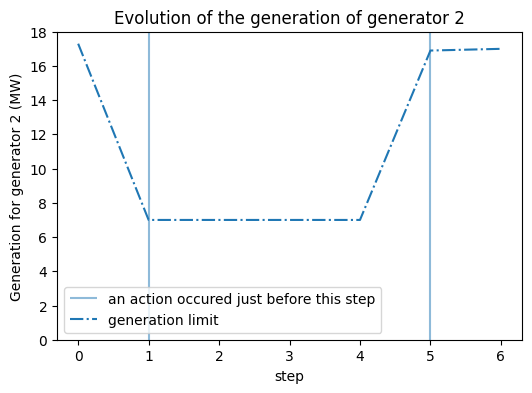

In [18]:
# and we can even plot it to see what's going on
plt.figure(figsize=(6,4))
plt.vlines(list([1, 5]), ymin=0., ymax=18, label="an action occured just before this step", alpha=0.5)
plt.plot([obs_init.gen_p[gen_id],
          obs.gen_p[gen_id],
          obs0.gen_p[gen_id],
          obs1.gen_p[gen_id],
          obs2.gen_p[gen_id],
          obs3.gen_p[gen_id],
          obs4.gen_p[gen_id],],
         label="generation limit", linestyle="-.")
plt.legend()
plt.ylim([0., 18])
plt.xlabel("step")
plt.title(f"Evolution of the generation of generator {gen_id}")
_ = plt.ylabel(f"Generation for generator {gen_id} (MW)")

## Example
An example of the behaviour of this feature is provided bellow. In this example, we perform 4 curtailment actions at 4 different steps (showed by vertical bars in the final graphs) and show, for generator 2:

- generation limit (this is the maximum allowed by the curtailment)
- effective curtailment (this is the total amount of MW that has been curtailed)
- reference generation (generation there would have been without curtailment)
- actual generation (the generation observed for this generator, the power that is really injected on the grid)
- sum of dispatch (total power absorbed by the dispatchable generator to compensate for the curtailment)

/qfs/projects/gridpack_wind/grid2op_interface/grid2op/grid2op/MakeEnv/Make.py:482: UserWarning: You are using a development environment. This environment is not intended for training agents. It might not be up to date and its primary use if for tests (hence the "test=True" you passed as argument). Use at your own risk.
  warnings.warn(_MAKE_DEV_ENV_WARN)


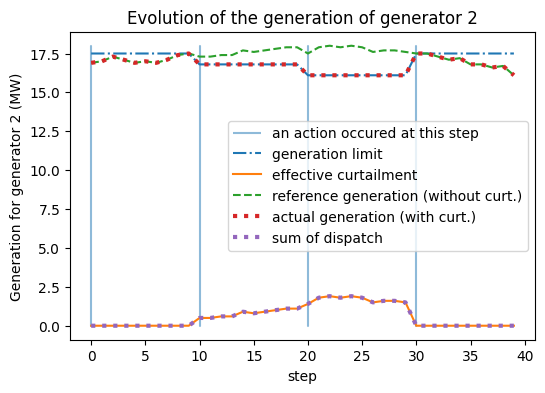

In [19]:
env1 = grid2op.make("educ_case14_storage", 
                    test=True,
                    action_class=PlayableAction,
                    param=param,
                    backend=bk_cls(with_numba=False))

gen_id = 2
ratios_max = [0.25, 0.24, 0.23, 0.25]  
n_steps = 40 
acts = []
prod1 = []
prod2 = []
curtailment_limit = []
curtail_gen1 = []
sum_disp = []
li_id_xplt = set()
for ratio in ratios_max:
    acts.append(env1.action_space({"curtail": [(gen_id, ratio)]}))
    
for step in range(n_steps):
    if step % 10 == 0:
        # execute a curtailment action
        li_id = step // 10
        li_id_xplt.add(step)
        ratio_max = ratios_max[li_id]
        obs1_3, reward1_3, done1_3, info1_3 = env1.step(acts[li_id])
    else:
        obs1_3, reward1_3, done1_3, info1_3 = env1.step(env1.action_space())
        
    if done1_3:
        raise RuntimeError("Environment did game over, this is not normal")
    if info1_3["exception"]:
        raise RuntimeError("Exception for info1_3")

    prod1.append(obs1_3.gen_p[gen_id])
    prod2.append(obs1_3.gen_p_before_curtail[gen_id])
    curtail_gen1.append(obs1_3.curtailment_mw[gen_id])
    curtailment_limit.append(obs1_3.curtailment_limit_mw[gen_id])
    sum_disp.append(obs1_3.actual_dispatch.sum())
    
plt.figure(figsize=(6,4))
plt.vlines(list(li_id_xplt), ymin=0., ymax=18., label="an action occured at this step", alpha=0.5)
plt.plot(curtailment_limit, label="generation limit", linestyle="-.")
plt.plot(curtail_gen1, label="effective curtailment")
plt.plot(prod2, label="reference generation (without curt.)", linestyle="--")
plt.plot(prod1, label="actual generation (with curt.)", linestyle=":", linewidth=3)
plt.plot(sum_disp, label="sum of dispatch", linestyle=":", linewidth=3)
plt.legend()
plt.xlabel("step")
plt.title(f"Evolution of the generation of generator {gen_id}")
_ = plt.ylabel(f"Generation for generator {gen_id} (MW)")

# Train an agent

In [16]:
import numpy as np
import grid2op
from grid2op.Action import CompleteAction, PlayableAction
from grid2op.Reward import L2RPNReward
from grid2op.gym_compat import GymEnv, BoxGymActSpace, BoxGymObsSpace
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv

In [25]:
# Define environment configuration
env_name = "l2rpn_case14_sandbox"  # You can choose any compatible environment

# Load the environment with curtailment action space
env = grid2op.make(
    env_name,
    action_class=PlayableAction,  
    reward_class=L2RPNReward,
    backend=bk_cls(with_numba=False)
)

In [26]:
# Wrap into a Gym-compatible environment
gym_env = GymEnv(env)

# Observation space
gym_env.observation_space = BoxGymObsSpace(env.observation_space, attr_to_keep=["rho"])

In [27]:
# Action space: curtailment vector between 0 and 1 for each renewable generator
act_space = BoxGymActSpace(env.action_space, attr_to_keep=["curtail"])
gym_env.action_space = act_space

In [28]:
# Convert to vectorized environment
vec_env = DummyVecEnv([lambda: gym_env])

In [29]:
# Optional: Evaluation callback
eval_callback = EvalCallback(
    vec_env,
    eval_freq=1000,
    best_model_save_path="./best_model/",
    deterministic=True,
    render=False,
)

In [30]:
# Initialize the RL model (PPO is a good default)
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    tensorboard_log="./ppo_curtailment_tensorboard/",
    learning_rate=3e-4,
    n_steps=2048,
    ent_coef=0.01,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
    clip_range_vf=None,
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
)

Using cpu device


In [ ]:
# Train the model
model.learn(
    total_timesteps=10,
    callback=eval_callback,
    tb_log_name="PPO"
)

Logging to ./ppo_curtailment_tensorboard/PPO_4
dgstrf info 9
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 9
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
dgstrf info 1
